<a href="https://colab.research.google.com/github/haftamugebremaryam16/Machine-Learning/blob/main/linear_regression_using_numpy_in_one_input_feature.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###### this one input feature simple linear regression model using numpy only  

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df=pd.read_csv('/content/simple_linear.csv')

In [3]:
df.head()

,x,y
0,1,15.483571
1,2,15.308678
2,3,22.238443
3,4,29.615149
4,5,23.829233


In [4]:

x = df["x"].values
y = df["y"].values

In [5]:
x=np.array(df['x'])
y=np.array(df['y'])

In [6]:
mu = np.mean(x)
sigma = np.std(x)

x_train = (x - mu) / sigma

In [16]:
def compute_cost(x, y, w, b):
    m = len(x)
    cost = 0

    f_x = np.dot(x, w) + b
    cost=np.mean((f_x-y)**2)

    return cost

In [27]:
def compute_gradient(x, y, w, b):
    m = len(x)
    dj_dw = 0
    dj_db = 0

    f_x = np.dot(x, w) + b
    error = f_x - y
    dj_dw = np.dot(x.T, error)
    dj_db = np.sum(error)
    dj_dw /= m
    dj_db /= m

    return dj_dw, dj_db

In [28]:
def gradient_descent(x, y, w, b, alpha, iterations):
    cost_history = []

    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(x, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(x, y, w, b)
        cost_history.append(cost)

        if i % 100 == 0:
            print("Iteration:", i, "Cost:", cost)

    return w, b, cost_history

Iteration: 0 Cost: 32803.66490609285
Iteration: 100 Cost: 4412.667459391443
Iteration: 200 Cost: 608.8508525891589
Iteration: 300 Cost: 99.21674039047197
Iteration: 400 Cost: 30.93612774156684
Iteration: 500 Cost: 21.7879134597639
Iteration: 600 Cost: 20.562238684757123
Iteration: 700 Cost: 20.398023176920177
Iteration: 800 Cost: 20.37602163657353
Iteration: 900 Cost: 20.373073877351533


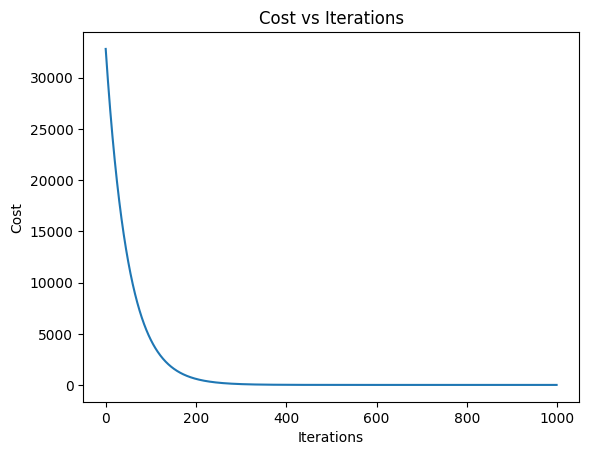

In [29]:
f_w,f_b,cost_history=gradient_descent(x_train,y,0,0,0.01,1000)
plt.plot(cost_history)
plt.title("Cost vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

In [30]:
y_pred=np.dot(x_train,f_w)+f_b
y_mean=np.mean(y)
sst=np.sum((y-y_mean)**2)
ssr=np.sum((y_pred-y_mean)**2)
r2=ssr/sst
print(r2)

0.9972171427663131
